In [1]:
import nest_asyncio
nest_asyncio.apply()

# Notebook 2 – Wind Power Reliability Analysis
**Goal:** Based on January 2024 actual wind generation data, determine how many MW of wind power can be reliably expected to meet electricity demand.

### Methodology
We use a **percentile-based capacity credit** approach:
- **P10 (10th percentile)** generation: conservative reliable floor (available 90% of time)
- **P50 (median)**: typical expected output
- **P90 (90th percentile)**: upper-end generation

The **P10 value is our recommended reliable capacity** — it represents what system operators can count on for demand planning with 90% confidence.


In [2]:

import asyncio
import httpx
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timezone
from dateutil import parser as dtparser

sns.set_theme(style="darkgrid")
plt.rcParams["figure.dpi"] = 120

BMRS_BASE = "https://data.elexon.co.uk/bmrs/api/v1"
HEADERS = {"Accept": "application/json", "User-Agent": "WindReliabilityNotebook/1.0"}

def parse_dt(s):
    dt = dtparser.parse(s)
    return dt.replace(tzinfo=timezone.utc) if dt.tzinfo is None else dt.astimezone(timezone.utc)

async def fetch_actuals():
    url = f"{BMRS_BASE}/datasets/FUELHH/stream"
    params = {"settlementDateFrom": "2024-01-01", "settlementDateTo": "2024-01-31",
              "fuelType": "WIND", "format": "json"}
    async with httpx.AsyncClient(timeout=120, follow_redirects=True) as c:
        r = await c.get(url, params=params, headers=HEADERS)
        r.raise_for_status()
        data = r.json()
    items = data if isinstance(data, list) else data.get("data", data.get("items", []))
    rows = []
    for item in items:
        try:
            if item.get("fuelType","").upper() != "WIND":
                continue
            rows.append({"time": parse_dt(item["startTime"]), "generation_mw": float(item["generation"])})
        except:
            pass
    df = pd.DataFrame(rows).drop_duplicates("time").sort_values("time").reset_index(drop=True)
    return df

print("Fetching January 2024 actuals…")
df = asyncio.run(fetch_actuals())
print(f"Loaded {len(df):,} half-hourly observations")
df.head()


Fetching January 2024 actuals…
Loaded 1,488 half-hourly observations


,time,generation_mw
0,2024-01-01 00:00:00+00:00,10402.0
1,2024-01-01 00:30:00+00:00,10845.0
2,2024-01-01 01:00:00+00:00,11218.0
3,2024-01-01 01:30:00+00:00,11223.0
4,2024-01-01 02:00:00+00:00,11234.0


In [3]:

# Basic statistics
desc = df["generation_mw"].describe(percentiles=[0.05,0.10,0.25,0.50,0.75,0.90,0.95])
print("=== January 2024 UK Wind Generation Statistics ===")
print(desc.round(1).to_string())


=== January 2024 UK Wind Generation Statistics ===
count     1488.0
mean      9848.7
std       3676.0
min          0.0
5%        4301.1
10%       5087.9
25%       6732.5
50%       9863.5
75%      13105.2
90%      14809.6
95%      15424.6
max      16662.0


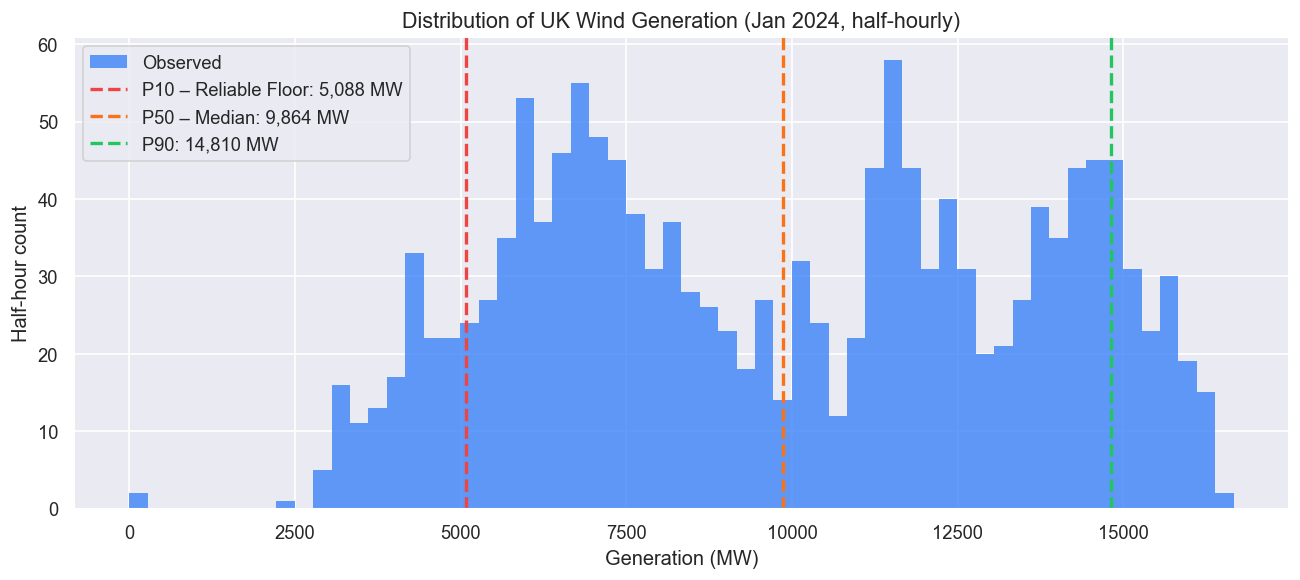

In [4]:

# ── Distribution plot ─────────────────────────────────────────────────────────
p10 = df["generation_mw"].quantile(0.10)
p50 = df["generation_mw"].quantile(0.50)
p90 = df["generation_mw"].quantile(0.90)

fig, ax = plt.subplots(figsize=(11, 5))
ax.hist(df["generation_mw"], bins=60, color="#3b82f6", edgecolor="none", alpha=0.8, label="Observed")
ax.axvline(p10, color="#ef4444",  lw=2, linestyle="--", label=f"P10 – Reliable Floor: {p10:,.0f} MW")
ax.axvline(p50, color="#f97316",  lw=2, linestyle="--", label=f"P50 – Median: {p50:,.0f} MW")
ax.axvline(p90, color="#22c55e",  lw=2, linestyle="--", label=f"P90: {p90:,.0f} MW")
ax.set_title("Distribution of UK Wind Generation (Jan 2024, half-hourly)", fontsize=13)
ax.set_xlabel("Generation (MW)"); ax.set_ylabel("Half-hour count")
ax.legend()
plt.tight_layout()
plt.savefig("wind_generation_distribution.png", bbox_inches="tight")
plt.show()


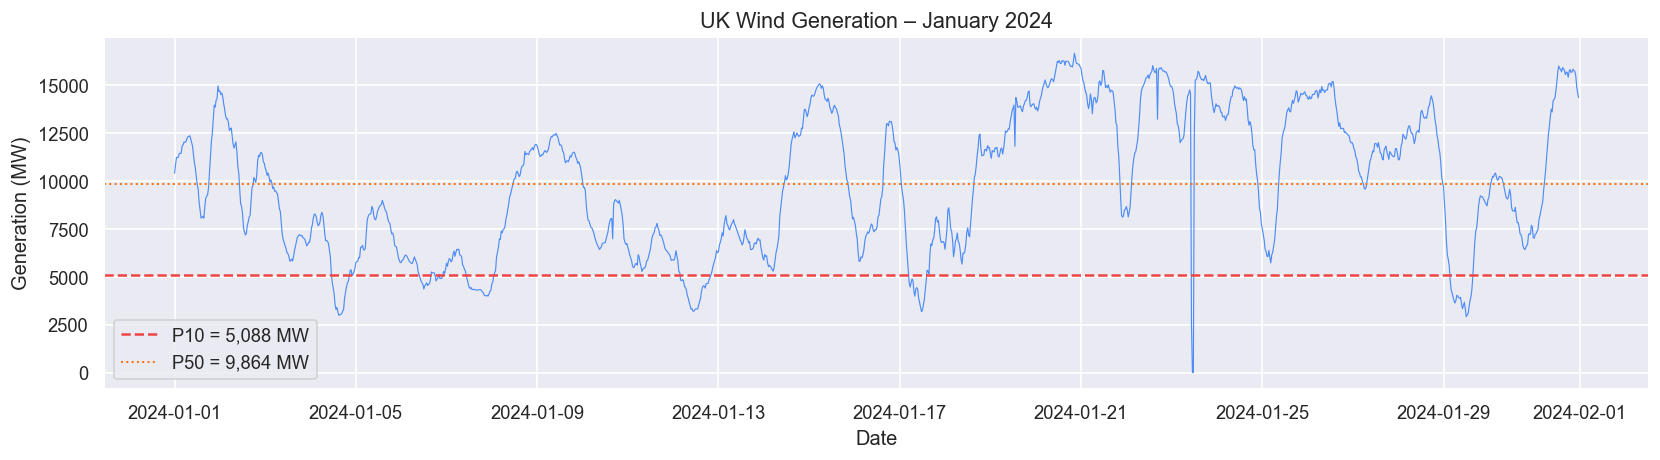

In [5]:

# ── Time-series overview ──────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(df["time"], df["generation_mw"], color="#3b82f6", lw=0.7, alpha=0.9)
ax.axhline(p10, color="#ef4444", lw=1.5, linestyle="--", label=f"P10 = {p10:,.0f} MW")
ax.axhline(p50, color="#f97316", lw=1.2, linestyle=":",  label=f"P50 = {p50:,.0f} MW")
ax.set_title("UK Wind Generation – January 2024", fontsize=13)
ax.set_xlabel("Date"); ax.set_ylabel("Generation (MW)")
ax.legend(); plt.tight_layout()
plt.savefig("wind_generation_timeseries.png", bbox_inches="tight")
plt.show()


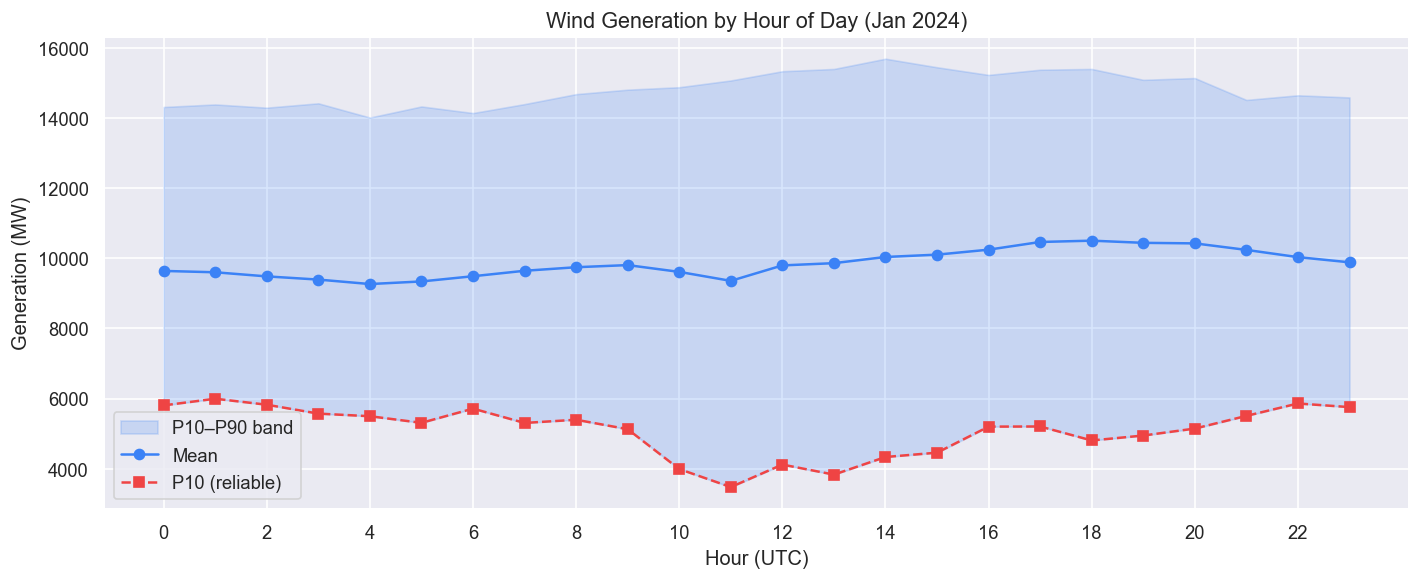

In [6]:

# ── Reliability by hour of day ────────────────────────────────────────────────
df["hour"] = df["time"].dt.hour
hourly = df.groupby("hour")["generation_mw"].agg(
    Mean="mean",
    P10=lambda x: np.percentile(x, 10),
    P50=lambda x: np.percentile(x, 50),
    P90=lambda x: np.percentile(x, 90),
)

fig, ax = plt.subplots(figsize=(12, 5))
ax.fill_between(hourly.index, hourly["P10"], hourly["P90"], alpha=0.2, color="#3b82f6", label="P10–P90 band")
ax.plot(hourly.index, hourly["Mean"], color="#3b82f6", marker="o", label="Mean")
ax.plot(hourly.index, hourly["P10"],  color="#ef4444", marker="s", linestyle="--", label="P10 (reliable)")
ax.set_title("Wind Generation by Hour of Day (Jan 2024)", fontsize=13)
ax.set_xlabel("Hour (UTC)"); ax.set_ylabel("Generation (MW)")
ax.set_xticks(range(0,24,2)); ax.legend()
plt.tight_layout()
plt.savefig("wind_reliability_by_hour.png", bbox_inches="tight")
plt.show()


Days with at least one interval below 2466 MW (25% of median): 1/31


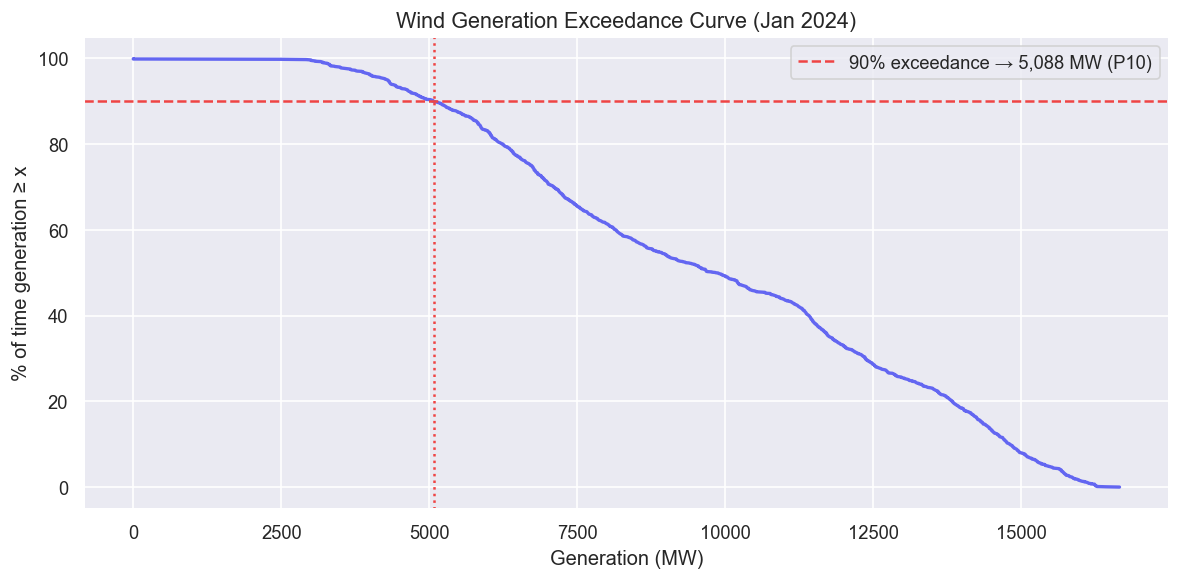

In [7]:

# ── Days where wind dropped below 25% of P50 (low-wind events) ───────────────
df["date"] = df["time"].dt.date
daily_min = df.groupby("date")["generation_mw"].min()
low_wind_threshold = p50 * 0.25
low_wind_days = (daily_min < low_wind_threshold).sum()
print(f"Days with at least one interval below {low_wind_threshold:.0f} MW (25% of median): {low_wind_days}/31")

# Exceedance curve (load-duration style)
sorted_gen = np.sort(df["generation_mw"].values)
exceedance = 1 - np.arange(1, len(sorted_gen)+1) / len(sorted_gen)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(sorted_gen, exceedance * 100, color="#6366f1", lw=2)
ax.axhline(90, color="#ef4444", linestyle="--", lw=1.5, label=f"90% exceedance → {p10:,.0f} MW (P10)")
ax.axvline(p10, color="#ef4444", linestyle=":", lw=1.5)
ax.set_title("Wind Generation Exceedance Curve (Jan 2024)", fontsize=13)
ax.set_xlabel("Generation (MW)"); ax.set_ylabel("% of time generation ≥ x")
ax.legend(); plt.tight_layout()
plt.savefig("wind_exceedance_curve.png", bbox_inches="tight")
plt.show()


## Recommendation

### How many MW of wind power can we reliably expect?

Based on January 2024 half-hourly BMRS data, the key statistics are:

| Metric | Value |
|--------|-------|
| Mean generation | see `desc` output |
| **P10 (reliable floor — 90% confidence)** | **see `p10` output** |
| P50 (median) | see `p50` output |
| P90 | see `p90` output |

### Our Recommendation: **Use the P10 value as the reliable capacity credit**

**Rationale:**

1. **Wind is intermittent by nature.** Planning around mean or P50 would leave demand exposed during the 50% of periods when generation falls below the median.

2. **The P10 value provides a 90% confidence floor.** System operators and grid planners conventionally use this metric when committing to demand cover from variable renewables. It answers: "What can we count on being there at least 90% of the time?"

3. **Low-wind events are real and clustered.** The time-series shows multi-day periods where generation drops sharply. The exceedance curve quantifies this risk explicitly.

4. **Recommendation for operational planning:** Use the P10 value as the reliable MW contribution from UK wind for demand-balancing purposes. Anything above P10 is a bonus that reduces reliance on dispatchable (gas/nuclear) backup but cannot be guaranteed.

5. **Caveat:** January is a single month. A full-year analysis would capture seasonal variation (summer wind is typically lower in the UK). A 12-month P10 would be a more robust planning figure.
